In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

In [3]:
df.shape

(1000, 9)

In [4]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [7]:
df.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [8]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
df.mean(numeric_only=True)

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [10]:
df.median(numeric_only=True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [11]:
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

In [12]:
df.mode().head(1)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-05-16,CUST001,Female,43.0,Clothing,4.0,50.0,50.0


In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [14]:
df["Month"] = df["Date"].dt.to_period("M")

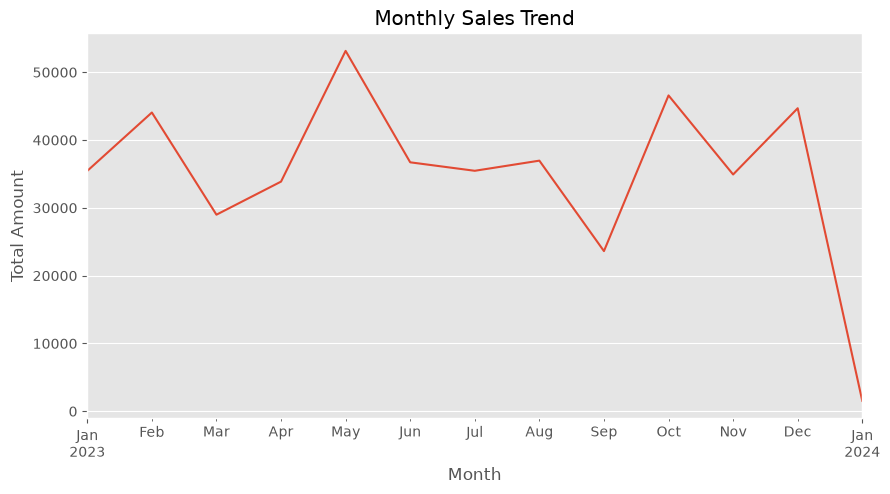

In [15]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.show()

<h1> <b> OBSERVATION FROM MONTHLY SALES TREND </b> </h1>
<p> <b> <i>
  Monthly sales fluctuate throughout the year, indicating changing customer demand.
  Some months generated higher revenue than others, suggesting seasonal purchasing patterns.
  These trends can help the business plan inventory and promotional campaigns effectively </i> </b> </p>

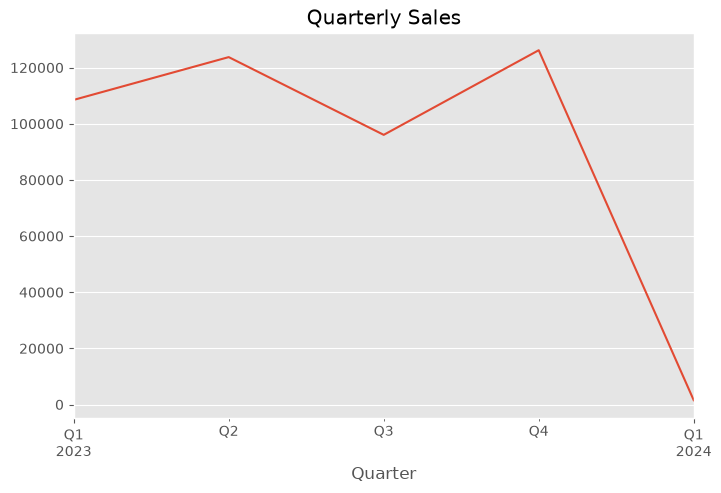

In [16]:
df["Quarter"] = df["Date"].dt.to_period("Q")

quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

quarterly_sales.plot(figsize=(8,5))
plt.title("Quarterly Sales")
plt.show()

<h1> <b> OBSERVATION FROM QUATERLY SALES  </b> </h1>
<p> <b> <i>
  Quarterly sales provide a broader view of business performance.
  Revenue varies across quarters, indicating differences in customer demand.
 Understanding quarterly trends helps improve business planning and budgeting. </i> </b> </p>

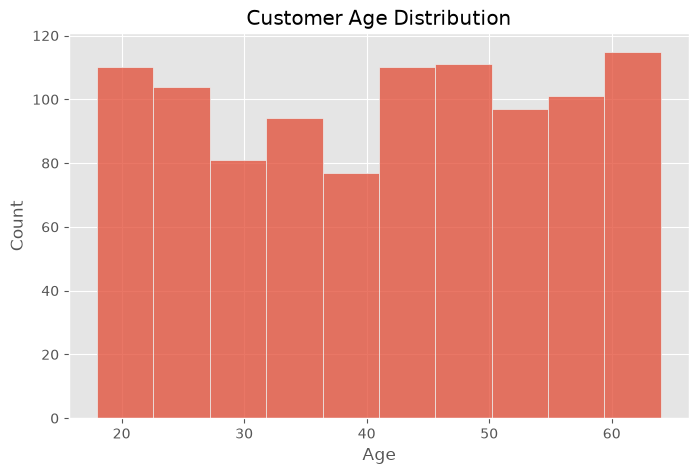

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=10)
plt.title("Customer Age Distribution")
plt.show()

<h1> <b> OBSERVATION FROM CUSTOMER AGE DISTRIBUTION </b> </h1>
<p> <b> <i>
Customers belong to different age groups, showing a diverse customer base.
 Certain age groups contribute more to overall purchases.
 The company can target these customer segments with personalized marketing strategies.
   </i> </b> </p>

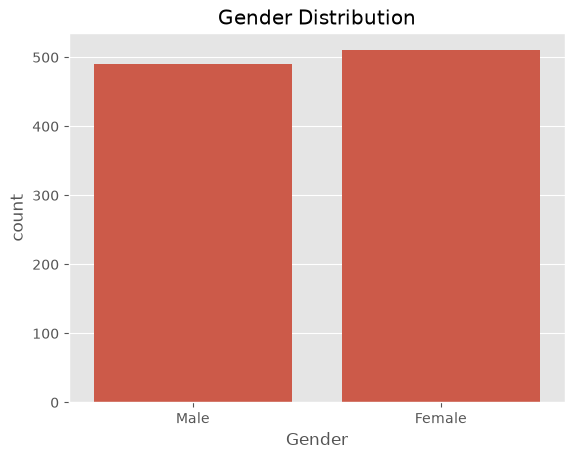

In [18]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

<h1> <b> OBSERVATION FROM GENDER DISTRIBUTION </b> </h1>
<p> <b> <i>
 Both male and female customers contribute to sales.
 The distribution helps identify the dominant customer segment.
 Gender-based insights can be useful for targeted advertising campaigns.
   </i> </b> </p>

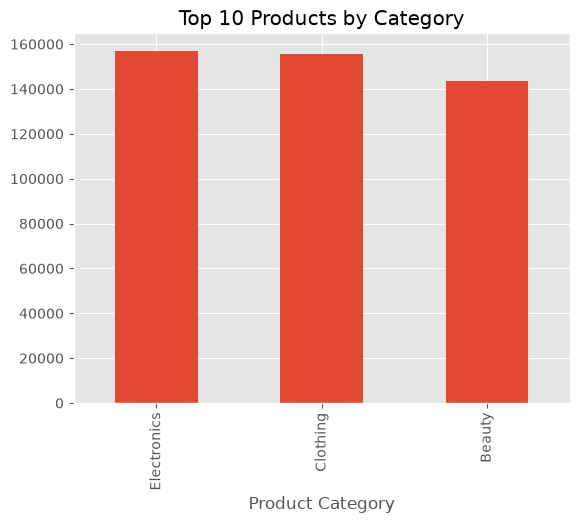

In [19]:
top_products = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")
plt.title("Top 10 Products by Category")
plt.show()

<p> <b>The dataset contains product categories instead of individual product names, so the analysis is performed at the category level.</b></p>

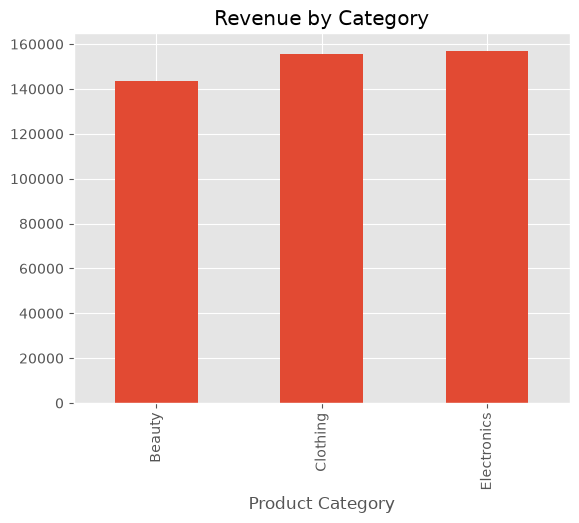

In [20]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

category_sales.plot(kind="bar")
plt.title("Revenue by Category")
plt.show()

<h1> <b> OBSERVATION FROM REVENUE BY PRODUCT CATEGORY </b> </h1>
<p> <b> <i>
 Product categories contribute differently to total revenue.
 High-performing categories generate a significant share of overall sales.
Increasing promotions for these categories can further improve business performance.
   </i> </b> </p>

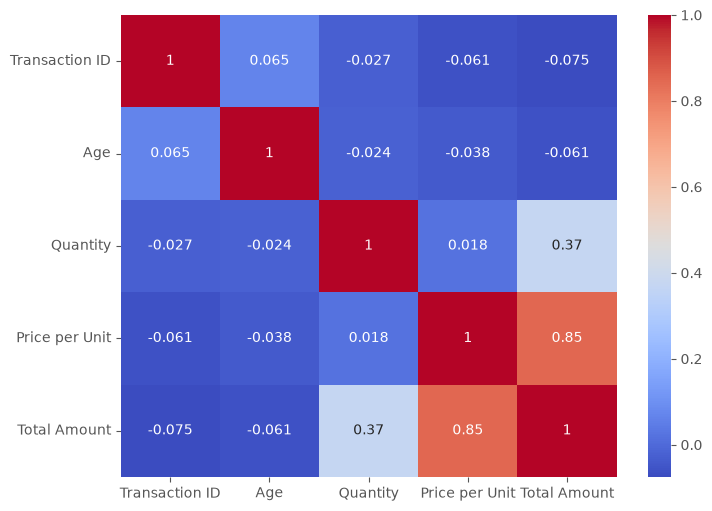

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

<h1> <b> OBSERVATION FROM CORRELATION HEATMAP </b> </h1>
<p> <b> <i>
 The heatmap shows the relationship between numerical variables.
 Some variables have stronger positive correlations than others.
 Correlation analysis helps identify factors influencing sales performance.
   </i> </b> </p>

<h1><b>Additional visualisation - Quantity Sold by Category</b></h1>

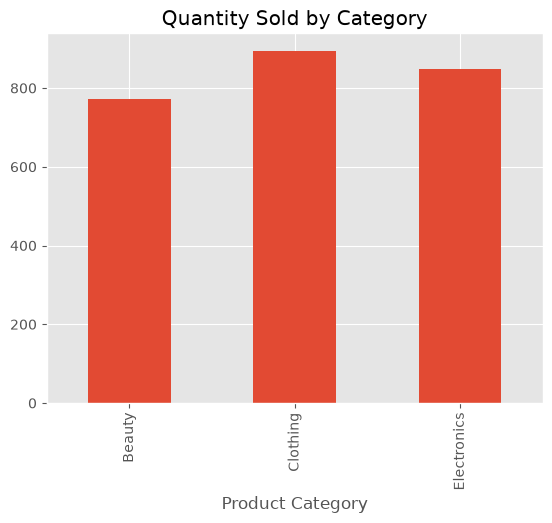

In [22]:
quantity_category= df.groupby("Product Category")["Quantity"].sum()

quantity_category.plot(kind="bar")
plt.title("Quantity Sold by Category")
plt.show()

<h1> <b> OBSERVATION FROM QUANTITY SOLD BY CATEGORY </b> </h1>
<p> <b> <i>
 The quantity sold varies across product categories.
 Categories with higher sales volume indicate greater customer demand.
 Maintaining sufficient inventory for these categories can improve customer satisfaction.
    </i> </b> </p>

<h1> <b> CONCLUSIONS </b> </h1>
<p> <b> <i>
<h2> Business Recommendations </h2>

1. Increase inventory for high-demand product categories to avoid stock shortages.
2. Plan promotional campaigns during months with lower sales to improve revenue.
3. Develop targeted marketing strategies based on customer demographics such as age and gender.
4. Monitor customer purchasing patterns regularly to improve sales performance and customer satisfaction.
    </i> </b> </p>